In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import joblib

In [17]:
df = pd.read_csv('../data/raw/Marine_Microplastics.csv')
print(df.shape)
df.head()

(20425, 22)


,OBJECTID,Oceans,Regions,SubRegions,Sampling Method,Measurement,Unit,Density Range,Density Class,Short Reference,...,Organization,Keywords,Accession Number,Accession Link,Latitude,Longitude,Date,GlobalID,x,y
0,9676,Atlantic Ocean,NaN,NaN,Grab sample,0.018,pieces/m3,0.005-1,Medium,Barrows et al.2018,...,Adventure Scientist,Adventure Scientist/Citizen Science,211009,https://www.ncei.noaa.gov/access/metadata/land...,-31.696000,-48.560000,8/11/2015 12:00:00 AM,a77121b2-e113-444e-82d9-7af11d62fdd2,-48.560000,-31.696000
1,6427,Pacific Ocean,NaN,NaN,Neuston net,0.000,pieces/m3,0-0.0005,Very Low,Law et al.2014,...,Sea Education Association,SEA,211008,https://www.ncei.noaa.gov/access/metadata/land...,6.350000,-121.850000,12/18/2002 12:00:00 AM,be27c450-02ca-4261-8d89-cae21108e6cc,-121.850000,6.350000
2,10672,Pacific Ocean,NaN,NaN,Manta net,0.013,pieces/m3,0.005-1,Medium,Goldstein et al.2013,...,Scripps Institution of Oceanography-University...,Great Pacific Garbage Patch/SEAPLEX,253448,https://www.ncei.noaa.gov/access/metadata/land...,0.500000,-95.350000,10/17/2006 12:00:00 AM,23effcdd-35b7-4e1e-adb4-390693a287d3,-95.350000,0.500000
3,13921,Atlantic Ocean,NaN,NaN,Aluminum bucket,1368.000,pieces/m3,>=10,Very High,Queiroz et al.2022,...,"Federal University of Pará, Brazil",Amazon Continental Shelf,276482,https://www.ncei.noaa.gov/access/metadata/land...,0.631825,-45.398158,10/17/2018 12:00:00 AM,16d77822-0533-4116-97b9-0bdb592f3d6e,-45.398158,0.631825
4,9344,Pacific Ocean,NaN,NaN,Grab sample,0.001,pieces/m3,0.0005-0.005,Low,Barrows et al.2018,...,Adventure Scientist,Adventure Scientist/Citizen Science,211009,https://www.ncei.noaa.gov/access/metadata/land...,16.623000,-99.697800,1/3/2015 12:00:00 AM,b9e435e3-9e86-4143-8b51-877e5dcdc7a6,-99.697800,16.623000


In [18]:
features = ["Latitude", "Longitude", "Measurement"]

X = df[features]

In [20]:
X = X.dropna()

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[X.index, "cluster"] = kmeans.fit_predict(X)

In [22]:
score = silhouette_score(X, df.loc[X.index, "cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.9928558911519172


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

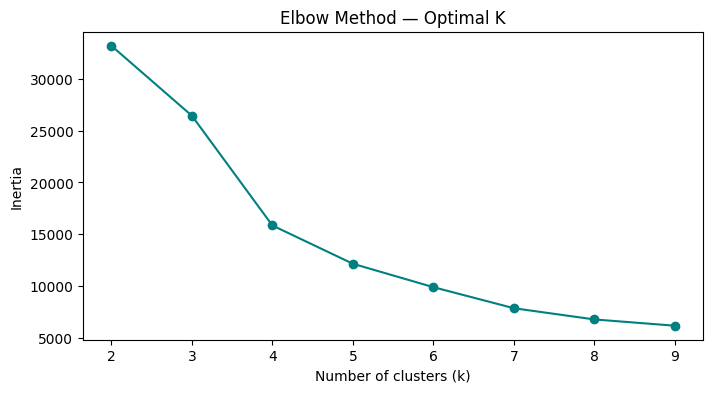

In [26]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='teal')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.savefig('../outputs/graphs/elbow_plot.png')
plt.show()

In [27]:
joblib.dump(kmeans, "../models/clustering/kmeans_model.pkl")

['../models/clustering/kmeans_model.pkl']

In [28]:
cluster_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}

df["cluster_label"] = df["cluster"].map(cluster_map)

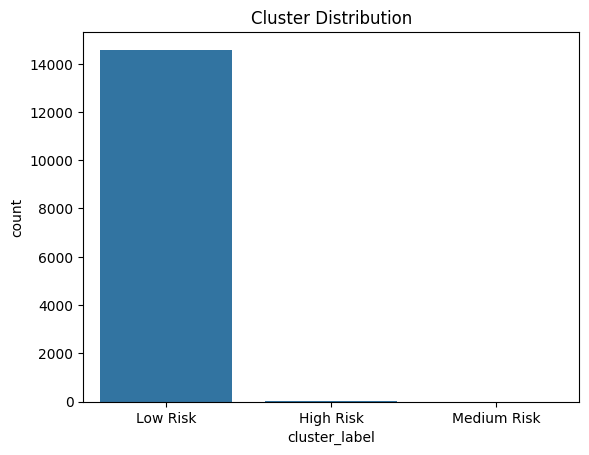

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="cluster_label", data=df)
plt.title("Cluster Distribution")
plt.show()

In [30]:
df.to_csv("../data/features/final_clustered_data.csv", index=False)

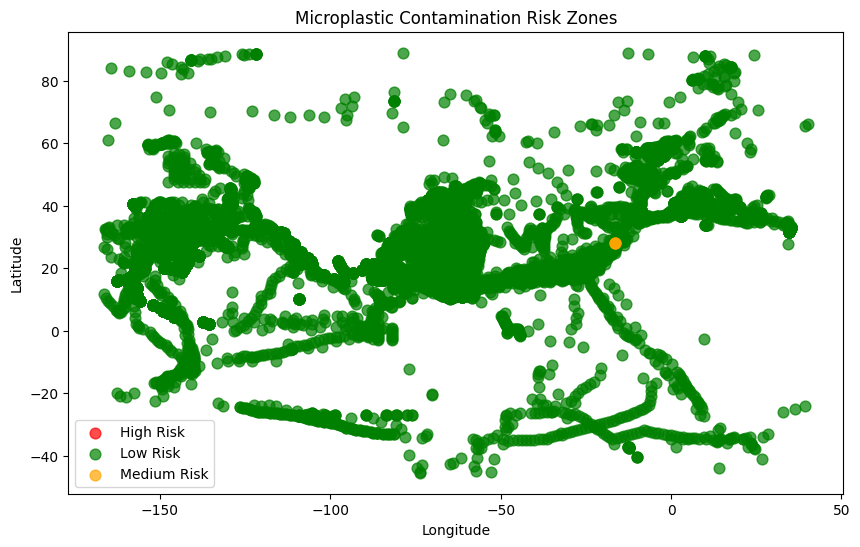

In [32]:
plt.figure(figsize=(10, 6))
colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}

for zone, grp in df.groupby('cluster_label'):
    plt.scatter(grp['Longitude'], grp['Latitude'],
                label=zone, color=colors[zone], alpha=0.7, s=60)

plt.title('Microplastic Contamination Risk Zones')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.savefig('../outputs/graphs/cluster_map.png')
plt.show()

In [33]:
import os
os.makedirs('../models/clustering', exist_ok=True)

joblib.dump(kmeans, '../models/clustering/kmeans_model.pkl')
joblib.dump(scaler, '../models/clustering/scaler.pkl')

# Save clustered data for Samaira to use in GIS maps
df.to_csv('../data/features/clustered_data.csv', index=False)
print("Model saved successfully!")

Model saved successfully!


In [34]:
import joblib

model = joblib.load('../models/clustering/kmeans_model.pkl')
scaler = joblib.load('../models/clustering/scaler.pkl')

print("Number of clusters:", model.n_clusters)
print("Cluster centers:\n", model.cluster_centers_)
print("Scaler mean:", scaler.mean_)

Number of clusters: 3
Cluster centers:
 [[ 2.73951624e+01 -7.71678677e+01  7.88456723e+01]
 [ 2.81525190e+01 -1.64317900e+01  9.97333333e+04]
 [ 2.84911600e+01 -2.20092645e+01  3.53071753e+04]]
Scaler mean: [ 27.39726796 -77.0572585  161.98397611]
